<a href="https://colab.research.google.com/github/ultimatepin/card_recognizer/blob/main/notebooks/03_automatic_crop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
%cd /content

!rm -rf card_recognizer
!git clone https://github.com/ultimatepin/card_recognizer.git

%cd /content/card_recognizer

/content
Cloning into 'card_recognizer'...
remote: Enumerating objects: 118, done.
remote: Counting objects: 100% (118/118), done.
remote: Compressing objects: 100% (109/109), done.
remote: Total 118 (delta 46), reused 38 (delta 5), pack-reused 0 (from 0)
Receiving objects: 100% (118/118), 14.62 MiB | 22.41 MiB/s, done.
Resolving deltas: 100% (46/46), done.
/content/card_recognizer


## Load image

(4032, 3024, 3)


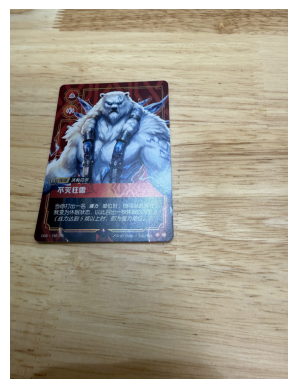

In [14]:
# headless means non GUI
!pip -q install opencv-python-headless

import cv2
import matplotlib.pyplot as plt

# opencv image is a numpy array
image = cv2.imread("queries/OGN-249_1.jpg")

# image[y, x] = [B, G, R]
print(image.shape)

plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

## Converts to greyscale

(4032, 3024)


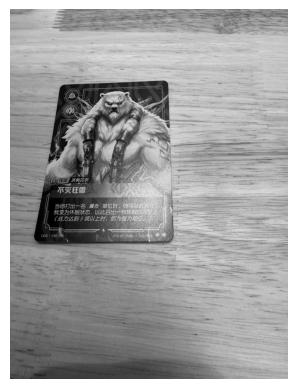

In [15]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# greyscale is just a single brightness
print(gray.shape)

# default plots a heatmap, cmap changes it to grayscale
plt.imshow(gray, cmap="gray")
plt.axis("off")
plt.show()

The dark card edge and light table shows a strong contrast.

## Canny edge detection

Canny calculates the brightness change (edge strength) and direction using Sobel filters.

There are two edge thresholds as parameters.
- Edge strength < lower boundary -> no edge
- Edge strength > upper boundary -> strong edge
- else -> weak edge

Weak edges are only kept when connected to a strong edge, this means Canny is less likely to produce broken edges. This is called hysteresis thresholding.

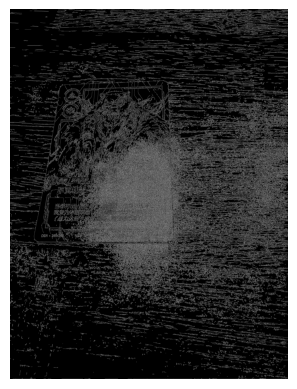

In [19]:
edges = cv2.Canny(gray, 50, 150)

plt.imshow(edges, cmap="gray")
plt.axis("off")
plt.show()

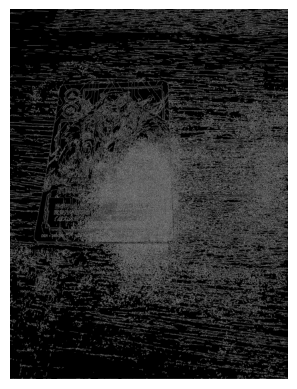

In [21]:
edges = cv2.Canny(gray, 20, 60)

plt.imshow(edges, cmap="gray")
plt.axis("off")
plt.show()